<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/neural_network_basics/experiment_activation_functions_comparison_and_mlp_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Generate Input Values

In [ ]:
x = np.linspace(-10, 10, 1000)

Define Activation Functions

Sigmoid
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$


In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

Tanh
$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$


In [ ]:
def tanh(x):
    return np.tanh(x)

ReLU

$$f(x)=max(0,x)$$

In [ ]:
def relu(x):
    return np.maximum(0, x)

Leaky ReLU

$$f(x)=max(0.01x,x)$$

In [ ]:
def leaky_relu(x):
    return np.maximum(0.01 * x, x)

ELU
$$f(x) = \begin{cases} x & \text{if } x > 0 \\ \alpha(e^x - 1) & \text{if } x \le 0 \end{cases}$$


In [ ]:
def elu(x, alpha=1):
    return np.where(
        x > 0,
        x,
        alpha * (np.exp(x) - 1)
    )

Plot Activation Functions

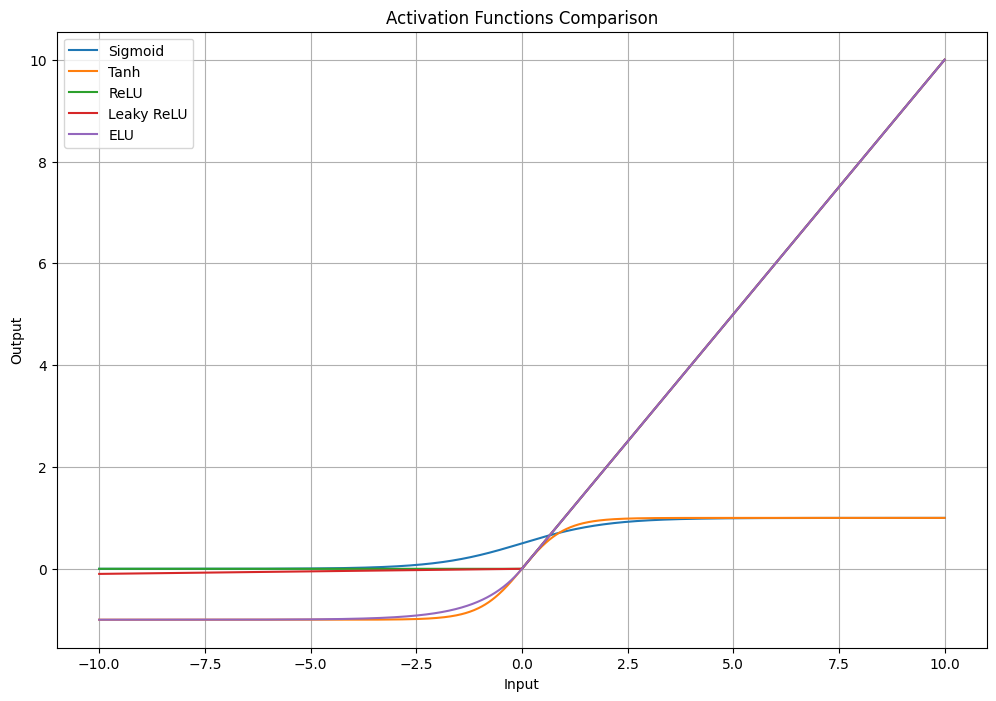

In [ ]:
plt.figure(figsize=(12, 8))

plt.plot(x, sigmoid(x), label="Sigmoid")

plt.plot(x, tanh(x), label="Tanh")

plt.plot(x, relu(x), label="ReLU")

plt.plot(x, leaky_relu(x), label="Leaky ReLU")

plt.plot(x, elu(x), label="ELU")

plt.title("Activation Functions Comparison")

plt.xlabel("Input")

plt.ylabel("Output")

plt.legend()

plt.grid(True)

plt.show()

Derivatives of Activation Functions

Sigmoid Derivative

$$σ
′
(x)=σ(x)(1−σ(x))$$

In [ ]:
def sigmoid_derivative(x):

    s = sigmoid(x)

    return s * (1 - s)

Tanh Derivative

$$tanh
′
(x)=1−tanh^
2
(x)$$

In [ ]:
def tanh_derivative(x):

    return 1 - np.tanh(x)**2

ReLU Derivative

$$f'(x) = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{if } x \le 0 \end{cases}$$


In [ ]:
def relu_derivative(x):

    return np.where(x > 0, 1, 0)

Plot Derivatives


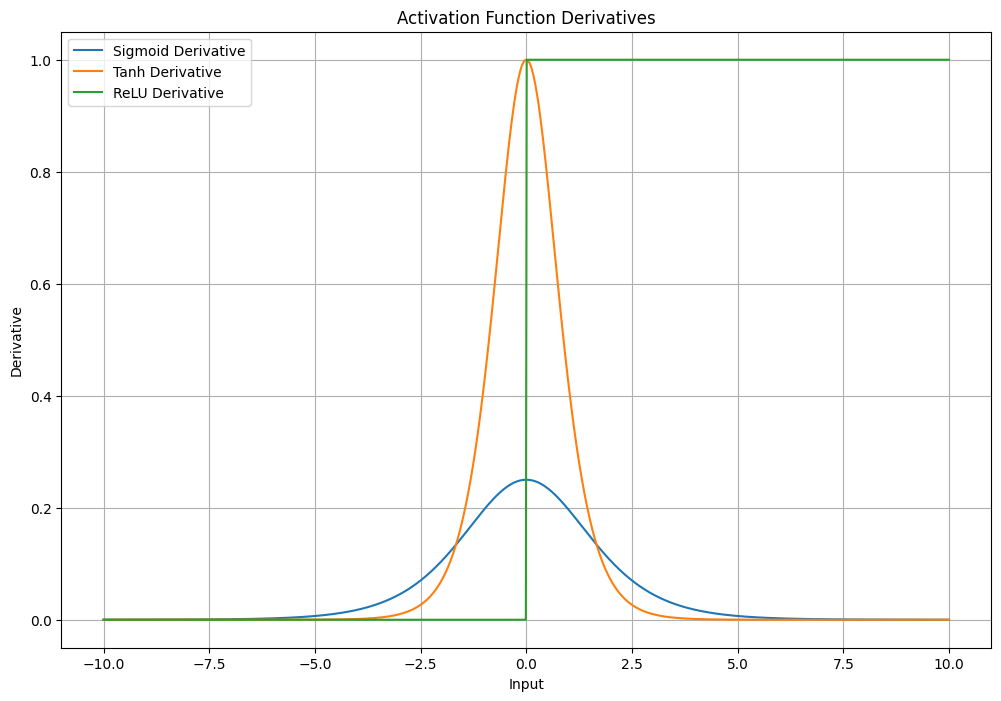

In [ ]:
plt.figure(figsize=(12, 8))

plt.plot(
    x,
    sigmoid_derivative(x),
    label="Sigmoid Derivative"
)

plt.plot(
    x,
    tanh_derivative(x),
    label="Tanh Derivative"
)

plt.plot(
    x,
    relu_derivative(x),
    label="ReLU Derivative"
)

plt.title("Activation Function Derivatives")

plt.xlabel("Input")

plt.ylabel("Derivative")

plt.legend()

plt.grid(True)

plt.show()

# **Experimental Comparison on Real Dataset**

Using Iris Dataset.

In [ ]:
from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Compare Activations Experimentally

In [ ]:
activations = [
    "identity",
    "logistic",
    "tanh",
    "relu"
]

results = []

for activation in activations:

    model = MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation=activation,
        max_iter=2000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    results.append([
        activation,
        accuracy
    ])

    print(
        f"{activation} Accuracy:",
        accuracy
    )

identity Accuracy: 0.9666666666666667
logistic Accuracy: 0.9666666666666667
tanh Accuracy: 1.0
relu Accuracy: 1.0


Convert Results to Table

In [ ]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Activation Function",
        "Accuracy"
    ]
)

print(results_df)

  Activation Function  Accuracy
0            identity  0.966667
1            logistic  0.966667
2                tanh  1.000000
3                relu  1.000000


Visualize Accuracy Comparison

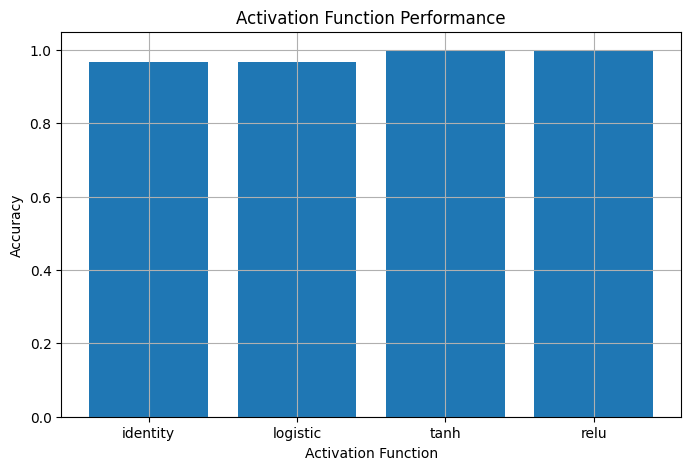

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Activation Function"],
    results_df["Accuracy"]
)

plt.title(
    "Activation Function Performance"
)

plt.xlabel("Activation Function")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()